<a href="https://colab.research.google.com/github/lalipedrozo/PUC_MVP_Machine_Learning/blob/main/MVP_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Larissa de Almeida Leite Pedrozo_  
**Matrícula:** _4052025002512_  
**Data:** _05/07/2026_  
**Dataset:** _https://www.kaggle.com/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data_  
**Tipo de problema:** _Séries Temporais_  

---

## Observações importantes

Este notebook é um **template** para o desenvolvimento do MVP da Sprint de Machine Learning & Analytics. Ele não deve ser preenchido de forma mecânica: adapte as seções ao problema escolhido e remova partes que não fizerem sentido.

O objetivo do MVP é demonstrar um fluxo completo e bem documentado de Machine Learning: definição do problema, entendimento dos dados, preparação, modelagem, avaliação e discussão crítica dos resultados.

> **Atenção:** profundidade e clareza valem mais do que quantidade de técnicas. É melhor apresentar uma solução simples, bem justificada e executável do que testar muitos modelos sem análise.

> **Atenção 2:** o dataset utilizado neste template é apenas um exemplo sintético para que o notebook execute sem erros. Substitua pela base escolhida, carregada por URL pública ou fonte diretamente acessível no Colab.


## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# (1) Definição do problema

## 1.1 Descrição do problema

O ouro é um dos ativos financeiros mais tradicionais do mercado e desempenha um papel importante como reserva de valor e instrumento de proteção em períodos de instabilidade econômica. Seu preço é influenciado por diversos fatores, como inflação, taxas de juros, câmbio, política monetária, oferta e demanda e eventos geopolíticos. Como consequência, seu comportamento apresenta variações ao longo do tempo que podem ser analisadas por meio de dados históricos.

Nesse contexto, a previsão do preço do ouro é um problema de interesse para investidores, analistas financeiros e instituições que acompanham o mercado de commodities. Embora não seja possível prever o mercado com total precisão, modelos de Machine Learning podem identificar padrões presentes nos dados históricos e produzir estimativas que auxiliem na tomada de decisão.

Neste MVP será desenvolvido um modelo capaz de prever o preço de fechamento do ouro para o próximo dia útil, utilizando informações históricas da própria série temporal e atributos derivados, como médias móveis, defasagens temporais e indicadores estatísticos. O objetivo não é substituir a análise financeira tradicional, mas investigar até que ponto técnicas de aprendizado de máquina conseguem capturar o comportamento histórico da série e gerar previsões consistentes.

A solução proposta pode ser útil como ferramenta de apoio para investidores, analistas de mercado e pesquisadores interessados em explorar aplicações de Machine Learning em séries temporais financeiras. Além disso, o projeto demonstra a aplicação prática das principais etapas de um fluxo de aprendizado de máquina, desde a preparação dos dados até a avaliação e comparação de diferentes modelos preditivos.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o preço de fechamento do ouro no próximo dia útil, utilizando dados históricos de preços e atributos derivados da série temporal. Para isso, serão comparados um modelo baseline e diferentes modelos preditivos, analisando seu desempenho por meio de métricas adequadas para problemas de regressão em séries temporais e discutindo suas principais limitações.


## 1.3 Tipo de problema

Tipo escolhido: Previsão de Séries Temporais (Forecasting)

Justificativa:

Este trabalho trata de um problema de previsão de séries temporais, cujo objetivo é estimar o preço de fechamento do ouro no próximo dia útil a partir de informações históricas. Como a variável de interesse é um valor numérico contínuo, o problema também pode ser interpretado como uma tarefa de regressão supervisionada.

A principal característica que diferencia este projeto de uma regressão tradicional é a existência de dependência temporal entre as observações. Dessa forma, a ordem cronológica dos dados deve ser preservada durante a preparação, divisão entre treino e teste e validação dos modelos, evitando vazamento de informações futuras para o processo de treinamento. Por esse motivo, não será utilizado embaralhamento aleatório dos dados, mas sim uma estratégia de divisão temporal compatível com problemas de forecasting.


## 1.4 Premissas, hipóteses e critérios de sucesso

Hipóteses iniciais:

- Hipótese 1: O comportamento histórico do preço do ouro contém padrões temporais que podem ser explorados por modelos de Machine Learning para prever o preço de fechamento do próximo dia útil.

- Hipótese 2: A utilização de atributos derivados da série temporal, como defasagens (lags), médias móveis e medidas de volatilidade, proporcionará melhor desempenho preditivo do que utilizar apenas os preços históricos originais.

- Hipótese 3: Modelos de aprendizado de máquina capazes de capturar relações não lineares, como Random Forest e Gradient Boosting, apresentarão desempenho superior ao de um modelo linear e ao baseline ingênuo.

Critérios de sucesso:

- Métrica principal: MAE (Mean Absolute Error), complementado por RMSE, MAPE e R² para uma avaliação mais completa do desempenho dos modelos.

- Resultado esperado: Obter um modelo que apresente desempenho superior ao baseline (Naive Forecast) nas métricas de erro, demonstrando que o aprendizado de máquina agrega capacidade preditiva em relação a uma abordagem ingênua.

- Restrições práticas: O modelo deve apresentar baixo custo computacional, ser reproduzível em ambiente Google Colab e utilizar apenas informações disponíveis até o instante da previsão, evitando vazamento de dados e respeitando a ordem temporal da série.

# (2) Ambiente, bibliotecas e reprodutibilidade

Este projeto foi desenvolvido em Python utilizando o Google Colab. Foram utilizadas bibliotecas amplamente empregadas em projetos de Ciência de Dados e Machine Learning, incluindo NumPy, Pandas, Matplotlib e Scikit-learn.

Para garantir a reprodutibilidade dos resultados, foi fixada uma seed (SEED = 42) para os geradores de números aleatórios utilizados ao longo do projeto. Dessa forma, processos que envolvem aleatoriedade, como o treinamento de alguns modelos e a otimização de hiperparâmetros, poderão produzir resultados consistentes em diferentes execuções.

O treinamento será realizado utilizando CPU, não sendo necessária aceleração por GPU devido ao porte do conjunto de dados e à baixa complexidade computacional dos modelos avaliados.


In [14]:
# ==========================================================
# Setup do ambiente e reprodutibilidade
# ==========================================================

import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint

# Modelagem
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

warnings.filterwarnings("ignore")

# ==========================================================
# Reprodutibilidade
# ==========================================================

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Seed: {SEED}")

Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Não foi necessária a instalação de bibliotecas adicionais para o desenvolvimento deste projeto. Todas as etapas de preparação dos dados, treinamento, otimização e avaliação dos modelos foram realizadas utilizando bibliotecas disponíveis por padrão no ambiente do Google Colab e no ecossistema do Scikit-learn.

Essa escolha contribui para a reprodutibilidade do notebook, reduzindo a necessidade de configurações extras e aumentando a probabilidade de execução completa em diferentes ambientes.


## 2.2 Funções auxiliares

Para tornar o notebook mais organizado e evitar repetição de código, foram criadas funções auxiliares para calcular as métricas de avaliação dos modelos de regressão e apresentar os resultados de forma padronizada. Essa abordagem melhora a legibilidade do código e facilita a comparação entre os diferentes modelos treinados ao longo do projeto.


In [15]:
# ==========================================================
# Funções auxiliares
# ==========================================================

def evaluate_regression(y_true, y_pred):
    """
    Calcula as principais métricas de avaliação para problemas de regressão.
    """
    mse = mean_squared_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred)
    }


def show_results_table(results_dict):
    """
    Converte o dicionário de resultados em um DataFrame,
    facilitando a comparação entre os modelos.
    """
    return (
        pd.DataFrame(results_dict)
        .T
        .sort_values("MAE")
        .round(4)
    )


# (3) Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o Gold Price (2005–2026 Historical Price Data), disponibilizado publicamente na plataforma Kaggle. A base reúne informações históricas diárias sobre o mercado do ouro, incluindo preço de fechamento, abertura, máxima, mínima, volume negociado e variação percentual ao longo do período de 2005 a 2026.

Fonte original:
https://www.kaggle.com/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data

Para garantir a reprodutibilidade do notebook, conforme exigido neste MVP, os dados serão carregados por meio de uma URL pública, sem necessidade de autenticação, upload manual ou configuração adicional.

A escolha desse dataset foi motivada por três fatores principais:

- Contém uma série histórica extensa, com aproximadamente vinte anos de observações diárias, permitindo o treinamento e avaliação de modelos de previsão temporal;
- Apresenta atributos diretamente relacionados ao comportamento do preço do ouro, possibilitando a criação de variáveis derivadas, como defasagens temporais, médias móveis e indicadores de volatilidade;
- Possui dados públicos, amplamente utilizados para estudos acadêmicos e experimentos de análise de dados e aprendizado de máquina.

Como restrição, deve-se considerar que o dataset contém apenas informações históricas de mercado, não incorporando variáveis macroeconômicas externas, como inflação, taxas de juros, câmbio ou indicadores geopolíticos, que também podem influenciar o preço do ouro.

Do ponto de vista ético, não há questões relacionadas à privacidade ou confidencialidade, pois a base é composta exclusivamente por dados públicos de mercado, sem qualquer informação pessoal ou sensível. O uso dos dados neste projeto possui finalidade exclusivamente acadêmica.


## 3.2 Carga dos dados

O conjunto de dados foi carregado diretamente a partir de uma URL pública hospedada no GitHub, garantindo que o notebook possa ser executado integralmente sem necessidade de upload manual, autenticação ou configuração adicional. Após o carregamento, são apresentadas as primeiras observações do dataset para verificar se a importação foi realizada corretamente.


In [16]:
# Upload dataset

import pandas as pd

url = "https://raw.githubusercontent.com/lalipedrozo/PUC_MVP_Machine_Learning/refs/heads/main/Gold%20Futures%20Historical%20Data.csv"

df = pd.read_csv(url)

display(df.head())


,Date,Price,Open,High,Low,Vol.,Change %
0,01-03-2005,429.7,438.9,438.9,427.8,82850,-1.98
1,01-04-2005,429.2,430.4,431.3,424.8,54830,-0.12
2,01-05-2005,427.3,429,429.3,425.9,43720,-0.44
3,01-06-2005,421.6,427,428.3,421.1,65180,-1.33
4,01-07-2005,419.5,422.1,425.8,417.2,97970,-0.50


## 3.3 Visão geral do dataset

Antes da etapa de modelagem, é importante compreender a estrutura geral do conjunto de dados. Nesta seção são apresentadas informações sobre o tamanho da base, os tipos das variáveis, a existência de valores ausentes e registros duplicados, além de uma inspeção visual de algumas observações.

Como o objetivo deste MVP é construir um modelo de previsão de séries temporais, também será identificada a coluna que representa a dimensão temporal (Date) e discutida a variável que futuramente será utilizada como alvo da previsão. Nesta etapa, entretanto, a variável-alvo ainda não foi criada; ela será construída posteriormente a partir da coluna Price, representando o preço de fechamento do próximo dia útil.


In [17]:
print(f"Formato do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

print("\nTipos dos atributos:")
display(df.dtypes.rename("Tipo"))

print("\nInformações gerais:")
df.info()

Formato do dataset: 4997 linhas e 7 colunas

Tipos dos atributos:


,Tipo
Date,object
Price,object
Open,object
High,object
Low,object
Vol.,int64
Change %,float64



Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4997 entries, 0 to 4996
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4997 non-null   object 
 1   Price     4997 non-null   object 
 2   Open      4997 non-null   object 
 3   High      4997 non-null   object 
 4   Low       4997 non-null   object 
 5   Vol.      4997 non-null   int64  
 6   Change %  4997 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 273.4+ KB


In [18]:
print("Valores ausentes por coluna:")

display(
    df.isna()
      .sum()
      .rename("Valores ausentes")
      .to_frame()
)

Valores ausentes por coluna:


,Valores ausentes
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [19]:
duplicatas = df.duplicated().sum()

print(f"Registros duplicados: {duplicatas}")

Registros duplicados: 0


In [20]:
print("Amostra aleatória do dataset:")

display(df.sample(5, random_state=42))

Amostra aleatória do dataset:


,Date,Price,Open,High,Low,Vol.,Change %
84,05-04-2005,430,427.7,430.9,427.6,34460,0.54
4374,01/26/2023,"1,930.00","1,948.00","1,949.80","1,918.40",150900,-0.65
1497,12-06-2010,"1,416.10","1,415.10","1,429.40","1,409.80",144120,0.70
653,08-07-2007,682.3,683,683.9,677.4,52630,-0.15
877,06/23/2008,887.2,903.7,909.7,877.4,130320,-1.83


A inspeção inicial do dataset permite identificar algumas características importantes para as próximas etapas do projeto:

A coluna Date representa a ordem cronológica das observações e será utilizada para organizar a série temporal. Ela não será utilizada diretamente como variável preditora em seu formato original, mas servirá de base para a criação e ordenação temporal dos dados.
A coluna Price representa o preço de fechamento diário do ouro. Nesta etapa ela ainda faz parte do conjunto de atributos, mas posteriormente será utilizada para construir a variável-alvo (Target), correspondente ao preço de fechamento do próximo dia útil.
As demais colunas (Open, High, Low, Vol. e Change %) poderão ser utilizadas como variáveis explicativas, após os tratamentos e transformações necessários descritos na etapa de preparação dos dados.

## 3.4 Dicionário de dados

A tabela a seguir apresenta a descrição das variáveis originais do dataset e sua utilização prevista no desenvolvimento do modelo de Machine Learning.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **Date** | Data | Data de referência da cotação do ouro. | **Não (diretamente)** | Será utilizada para ordenar cronologicamente a série temporal, mas não como variável preditora em seu formato original.
| **Price** | Numérica | Preço de fechamento diário do ouro. | **Sim** | Será utilizada para construir a variável-alvo (`Target`) e também para gerar atributos derivados, como defasagens (lags) e médias móveis. |
| **Open** | Numérica | Preço de abertura do ouro no dia. | **Sim** | Variável explicativa que poderá auxiliar na previsão do preço de fechamento do próximo dia útil. |
| **High** | Numérica | Maior preço registrado durante o dia. | **Sim** | Variável explicativa relacionada à volatilidade diária. |
| **Low** | Numérica | Menor preço registrado durante o dia. | **Sim** | Variável explicativa relacionada à volatilidade diária. |
| **Vol.** | Numérica | Volume negociado no dia.| **Sim** | Será convertido para formato numérico durante a preparação dos dados. |
| **Change %** | Numérica | Variação percentual diária do preço do ouro. | **Sim** | Será convertida para formato numérico durante a preparação dos dados. |
| **Target** *(criada posteriormente)* | Variável-alvo | Preço de fechamento do ouro no próximo dia útil (`Price.shift(-1)`). | **Alvo** | Será criada na etapa de preparação dos dados e utilizada como variável dependente do modelo. |


As colunas Vol. e Change % encontram-se inicialmente em formato texto devido à presença de símbolos (como %, K, M e B) e serão convertidas para valores numéricos durante a etapa de preparação dos dados.

# (4) Análise exploratória dos dados

Antes da construção dos modelos de Machine Learning, foi realizada uma análise exploratória dos dados com o objetivo de compreender as principais características da série histórica do preço do ouro. Nesta etapa, busca-se identificar padrões temporais, comportamento das variáveis numéricas, possíveis valores extremos e relações entre os atributos disponíveis.

Como a variável-alvo será criada posteriormente a partir da coluna Price, a análise concentra-se inicialmente nas variáveis originais do dataset. As informações obtidas nesta etapa servirão de base para as decisões de preparação dos dados, engenharia de atributos e escolha dos modelos de previsão.


## 4.1 Preparação mínima para análise exploratória

Antes da análise exploratória, foi necessário realizar uma preparação mínima do conjunto de dados para garantir que as variáveis estivessem armazenadas nos tipos adequados. Essa etapa não tem como objetivo preparar os dados para os modelos de Machine Learning, mas apenas permitir a realização correta das análises estatísticas e das visualizações.

A coluna Date foi convertida para o tipo datetime, padronizando os diferentes separadores encontrados no dataset (- e /). As colunas Price, Open, High e Low foram convertidas para o tipo numérico (float), após a remoção dos separadores de milhar presentes em parte dos registros. Por fim, o conjunto de dados foi ordenado cronologicamente pela coluna Date, garantindo a correta sequência temporal da série histórica.




In [39]:
# ==========================================================
# Preparação mínima para análise exploratória
# ==========================================================

# Padroniza e converte a coluna de data
df["Date"] = df["Date"].str.replace("-", "/", regex=False)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="%m/%d/%Y"
)

# Converte as colunas de preços para valores numéricos
for col in ["Price", "Open", "High", "Low"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

# Ordena a série cronologicamente
df = df.sort_values("Date").reset_index(drop=True)

# Verifica os tipos finais das colunas
display(df.dtypes.to_frame("Tipo de dado"))

AttributeError: Can only use .str accessor with string values!

## 4.2 Estatísticas descritivas

## 4.3 Evolução histórica da série

## 4.4 Distribuição do preço de fechamento

## 4.5 Identificação de possíveis outliers

## 4.6 Correlação entre as variáveis

## 4.7 Síntese da análise exploratória

> Adicionar aspas



Escreva aqui os principais achados da EDA.

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> _Preencha aqui._


# (5) Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [ ]:
# === Configuração do problema ===
# Ajuste estas variáveis para o seu dataset.

TARGET = "churn"                  # para clusterização, use None
PROBLEM_TYPE = "classificacao"    # "classificacao", "regressao", "clusterizacao" ou "serie_temporal"
ID_COLUMNS = []                    # ex.: ["id_cliente"]
DATE_COLUMN = None                 # ex.: "data"; necessário para séries temporais
DROP_COLUMNS = []                  # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: churn
Número de features: 5
Features: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses', 'canal_aquisicao', 'usa_app']


In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (400, 5) | Teste: (100, 5)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> _Preencha aqui._


# (6) Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [ ]:
# Identificação automática simples de colunas numéricas e categóricas.
# Revise manualmente, especialmente se houver datas, IDs, texto livre ou categorias codificadas como números.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

# Se houver coluna de data entre as features, remova do pipeline tabular ou transforme antes.
if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)


Colunas numéricas: ['idade_cliente', 'renda_mensal', 'tempo_relacionamento_meses']
Colunas categóricas: ['canal_aquisicao', 'usa_app']


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> _Preencha aqui._


# (7) Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [ ]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

Explique por que os modelos escolhidos fazem sentido para este problema.

**O que comentar:**
- O baseline escolhido é coerente?
- Os modelos candidatos são adequados ao tipo e tamanho dos dados?
- Algum modelo exige escala, encoding ou tratamento específico?
- Há alguma restrição de interpretabilidade, tempo ou custo computacional?

**Resposta:**  
> _Preencha aqui._


# (8) Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [ ]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.60,0.450000,0.500000,0.077
LogisticRegression,0.74,0.738798,0.798333,0.078
RandomForest,0.65,0.650690,0.682500,0.844


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> _Preencha aqui._


# (9) Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [ ]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.

N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "f1_weighted"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,  # use 1 para evitar instabilidade em alguns ambientes de execução
        verbose=1
    )
    search.fit(X_train, y_train)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Melhor score na validação: 0.7512739088255881
Melhores hiperparâmetros: {'model__max_depth': 5, 'model__min_samples_split': 9, 'model__n_estimators': 201}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> _Preencha aqui._


# (10) Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.75      0.78      0.76        60
           1       0.65      0.60      0.62        40

    accuracy                           0.71       100
   macro avg       0.70      0.69      0.69       100
weighted avg       0.71      0.71      0.71       100



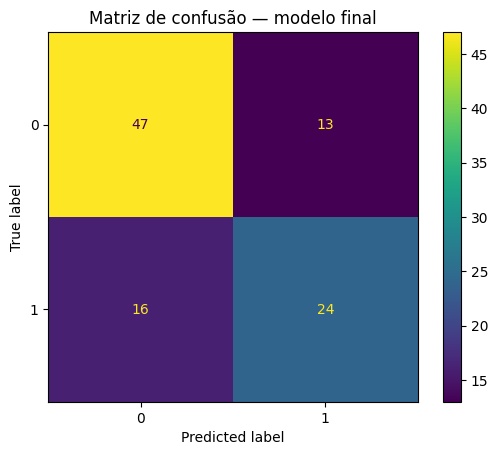

In [ ]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> _Preencha aqui._


# (11) Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 1 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo 2 | _preencha_ | _preencha_ | _preencha_ | _preencha_ |
| Modelo otimizado | _preencha_ | _preencha_ | _preencha_ | _preencha_ |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# (12) Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| _ex.: usar F1-score_ | _classes desbalanceadas_ | _avaliar melhor a classe minoritária_ |
| _ex.: remover coluna X_ | _vazamento de dados_ | _evitar desempenho artificial_ |
| _ex.: usar Random Forest_ | _capturar não linearidades_ | _melhorar baseline_ |


# (13) Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> _Preencha aqui._

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.


# (14) Salvamento de artefatos

Esta seção é opcional, mas recomendada quando o treinamento for demorado.

**O que pode ser salvo:**
- pipeline final;
- modelo treinado;
- encoder/scaler;
- tabela de resultados;
- gráficos importantes.

> **Comentário:** se salvar arquivos, garanta que o notebook continue executando do início ao fim. Não dependa de arquivos locais que o professor não terá.


In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final.
# Descomente se fizer sentido para o seu projeto.

# import joblib
# if final_model is not None:
#     joblib.dump(final_model, "modelo_final.pkl")
#     print("Modelo salvo como modelo_final.pkl")


# (15) Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Use esta seção apenas se o projeto realmente precisar.

**O que documentar se usar deep learning/fine-tuning:**
- arquitetura ou modelo pré-treinado;
- preparação específica dos dados;
- tamanho de batch;
- número de épocas;
- função de perda;
- otimizador;
- early stopping;
- uso de GPU/CPU;
- tempo de treino;
- comparação com baseline simples.

> **Comentário:** deep learning não é obrigatório. Um modelo clássico bem avaliado pode ser uma solução melhor para muitos MVPs.
